# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).


# Data: Social Activity Data

This notebook prepares social-media activity proxies used by subsequent UCI modelling stages.

This notebook exposes social activity data outputs for downstream modelling in-memory via `act_gdf`, and supports direct export to GeoPackage.

Primary handover fields:
- Index for the location: `id`
- Social activity intensity columns: `eating`, `nature`, `community`, `walking`, `sightseeing`
- Social activity comfort sentiment columns: `avg_comfort_score`, `avg_comfort_` + {`eating`, `nature`, `community`, `walking`, `sightseeing`}
- Social activity comfort columns: `social_activity_comfort_` + {`eating`, `nature`, `community`, `walking`, `sightseeing`}
- Derived indicators: `prevalent_activity`, `total_activity`, `prevalent_comfort_activity` (argmax over five `social_activity_comfort_*` columns), `total_social_activity_comfort` (sum of five comfort surfaces; used in Section 4)
- Coordinates: `longitude`, `latitude`
- Geometry: `geometry`

Data source used in this notebook:
- `data/data_social_activity.gpkg`


In [26]:
import plotly.graph_objects as go

# Flow:
# 1. Raw posts → posts with caption / posts without caption
# 2. Each splits into: used for clustering / excluded from cluster
# 3. Clustered posts further split into 5 activity categories

labels = [
    "Retrieved raw posts\n44,228",     # 0 - Raw posts
    "Posts with captions\n38,987",     # 1 - With caption
    "Posts without captions\n5,241",   # 2 - Without caption
    "Cluster selected posts\n33,250",  # 3 - Selected for clustering
    "Cluster excluded posts\n10,978",  # 4 - Not clustered
    "Eating posts\n10,313",            # 5
    "Nature posts\n3,834",             # 6
    "Community posts\n6,449",          # 7
    "Walking posts\n6,470",            # 8
    "Sightseeing posts\n6,184",        # 9
]

# Source and target node indices for each flow
source = [
    0, 0,           # raw → caption / no caption
    1, 1, 2, 2,     # with/without caption → clustered/excluded
    3, 3, 3, 3, 3,  # clustered→5 activities
]

target = [
    1, 2,
    3, 4, 3, 4,
    5, 6, 7, 8, 9,
]

# Flow values representing counts at each stage
value = [
    38987, 5241,
    29218, 9769, 4032, 1209,
    10313, 3834, 6449, 6470, 6184,
]

# Sankey Diagram construction
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=36,
                thickness=14,
                line=dict(color="rgba(80,80,80,0.5)", width=0.8),
                label=labels,
                x=[
                    0.02,          # Raw posts
                    0.20, 0.20,    # Caption splits
                    0.46, 0.46,    # Clustered / not
                    0.93, 0.93, 0.93, 0.93, 0.93, # Activity classes
                ],
                y=[
                    0.45,
                    0.25, 0.70,
                    0.28, 0.72,
                    0.05, 0.22, 0.40, 0.58, 0.76,
                ],
                color=[
                    "#BDDF26",                # Raw
                    "#72B7B2", "#E45756",     # Caption splits
                    "#7C7C7C", "#BAB0AC",     # Clustered / not
                    "#FF5445", "#29BB00", "#FFBC37", "#35A7FF", "#B339FF",  # Activities
                ],
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=[
                    # raw→caption/no_caption (match raw node color)
                    "rgba(189,223,38,0.42)", "rgba(189,223,38,0.42)",
                    # with caption→clustered/excluded (match node 1)
                    "rgba(114,183,178,0.45)", "rgba(114,183,178,0.26)",
                    # without caption→clustered/excluded (match node 2)
                    "rgba(228,87,86,0.45)", "rgba(228,87,86,0.26)",
                    # clustered→activities (match activity target nodes)
                    "rgba(255,84,69,0.5)",     # Eating
                    "rgba(41,187,0,0.5)",      # Nature
                    "rgba(255,188,55,0.5)",    # Community
                    "rgba(53,167,255,0.5)",    # Walking
                    "rgba(179,57,255,0.5)",    # Sightseeing
                ],
            ),
        )
    ]
)

fig.update_layout(
    title=dict(
        text="Social Media Post Data Filtering",
        x=0.5,
        xanchor="center",
    ),
    font=dict(size=13, family="Arial"),
    width=1400,
    height=820,
    margin=dict(l=40, r=40, t=80, b=40),
    paper_bgcolor="white",
    plot_bgcolor="white",
)

fig.show()


In [27]:
import plotly.graph_objects as go

# Text-free Sankey: same topology/colors as the block above, but no figure title and no node labels (for slides/posters).

labels = [""] * 10

source = [
    0, 0,
    1, 1, 2, 2,
    3, 3, 3, 3, 3,
]

target = [
    1, 2,
    3, 4, 3, 4,
    5, 6, 7, 8, 9,
]

value = [
    38987, 5241,
    29218, 9769, 4032, 1209,
    10313, 3834, 6449, 6470, 6184,
]

fig_clean = go.Figure(
    data=[
        go.Sankey(
            arrangement="fixed",
            hoverinfo="skip",
            node=dict(
                pad=36,
                thickness=14,
                line=dict(color="rgba(80,80,80,0.5)", width=0.8),
                label=labels,
                x=[
                    0.02,
                    0.20, 0.20,
                    0.46, 0.46,
                    0.93, 0.93, 0.93, 0.93, 0.93,
                ],
                y=[
                    0.45,
                    0.25, 0.70,
                    0.28, 0.72,
                    0.10, 0.24, 0.41, 0.58, 0.74,  # slightly inset from top/bottom to avoid clipping
                ],
                color=[
                    "#BDDF26",
                    "#72B7B2", "#E45756",
                    "#7C7C7C", "#BAB0AC",
                    "#FF5445", "#29BB00", "#FFBC37", "#35A7FF", "#B339FF",
                ],
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=[
                    "rgba(189,223,38,0.42)", "rgba(189,223,38,0.42)",
                    "rgba(114,183,178,0.45)", "rgba(114,183,178,0.26)",
                    "rgba(228,87,86,0.45)", "rgba(228,87,86,0.26)",
                    "rgba(255,84,69,0.5)",
                    "rgba(41,187,0,0.5)",
                    "rgba(255,188,55,0.5)",
                    "rgba(53,167,255,0.5)",
                    "rgba(179,57,255,0.5)",
                ],
            ),
        )
    ]
)

fig_clean.update_layout(
    title=None,
    annotations=[],
    width=1400,
    height=880,
    margin=dict(l=30, r=30, t=90, b=40),  # extra top/bottom so Sankey is not clipped
    paper_bgcolor="white",
    plot_bgcolor="white",
)

fig_clean.show()


## 1. Social Activity Intensity

We use social-media posting counts at each location $\mathbf{u}$ as a proxy of observed social activity intensity.

$$
\text{Activity Category Set } i = \{\textit{eating}, \textit{nature}, \textit{community}, \textit{walking}, \textit{sightseeing}\}
$$

$$
\text{SocialActivityIntensity}_{i,\mathbf{u}} = \text{PostNum}_{i,\mathbf{u}}
$$

Activity category definitions:
- `eating`: Eating and Drinking
- `nature`: Nature Exploration
- `community`: Community Gathering
- `walking`: Walking and Exercising
- `sightseeing`: Urban Sightseeing

This representation captures activity-specific participation patterns while preserving per-location comparability across categories.


In [2]:
import geopandas as gpd

# act_gdf: read social media intensity data as proxy for social activity
file_path = "./data/data_social_activity.gpkg"
act_gdf = gpd.read_file(file_path)

# This sets the coordinate reference system (CRS) of the 'act_gdf' GeoDataFrame to WGS 84 (EPSG:4326), 
# which is the standard geographic CRS using latitude and longitude.
act_gdf.crs = "EPSG:4326"

act_columns = ['eating', 'nature', 'community', 'walking', 'sightseeing']

print(act_gdf.crs)
print(act_gdf.columns)

# Calculate total number of activity posts per category and overall
for col in act_columns:
    print(f"Total number of valid activity posts ({col}): {act_gdf[col].sum()}")
print(f"Total number of valid activity posts across all locations: {act_gdf[act_columns].sum().sum()}")

EPSG:4326
Index(['id', 'longitude', 'latitude', 'eating', 'nature', 'community',
       'walking', 'sightseeing', 'avg_comfort_score', 'avg_comfort_eating',
       'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking',
       'avg_comfort_sightseeing', 'social_activity_comfort_eating',
       'social_activity_comfort_nature', 'social_activity_comfort_community',
       'social_activity_comfort_walking',
       'social_activity_comfort_sightseeing', 'geometry'],
      dtype='object')
Total number of valid activity posts (eating): 10313
Total number of valid activity posts (nature): 3834
Total number of valid activity posts (community): 6449
Total number of valid activity posts (walking): 6470
Total number of valid activity posts (sightseeing): 6184
Total number of valid activity posts across all locations: 33250


## 2. Prevalent Activity and Total Activity Intensity


For each location $\mathbf{u}$, we identify the most prevalent activity category (highest post count):

$$
\text{PrevalentActivity}_{\mathbf{u}} = \underset{i}{\mathrm{argmax}} \; \text{SocialActivityIntensity}_{i,\mathbf{u}}
$$

where $\text{SocialActivityIntensity}_{i,\mathbf{u}}$ is the number of posts for activity $i$ at location $\mathbf{u}$. If no activity posts exist (i.e., $\sum_i \text{SocialActivityIntensity}_{i,\mathbf{u}} = 0$), we assign $\text{PrevalentActivity}_{\mathbf{u}} = \text{none}$.

We also compute total activity intensity across all categories:

$$
\text{TotalActivityIntensity}_{\mathbf{u}} = \sum_{i} \text{SocialActivityIntensity}_{i,\mathbf{u}}
$$

These two indicators summarize dominant activity type and aggregate activity load at each location.


In [29]:
# Calculate which activity is the most prevalent (i.e., has the highest count) for each location.
act_gdf['prevalent_activity'] = act_gdf[act_columns].idxmax(axis=1)
act_gdf.loc[act_gdf[act_columns].sum(axis=1) == 0, 'prevalent_activity'] = 'none'
# Calculate the total number of activity posts across all categories for each location.
act_gdf['total_activity'] = act_gdf[act_columns].sum(axis=1)

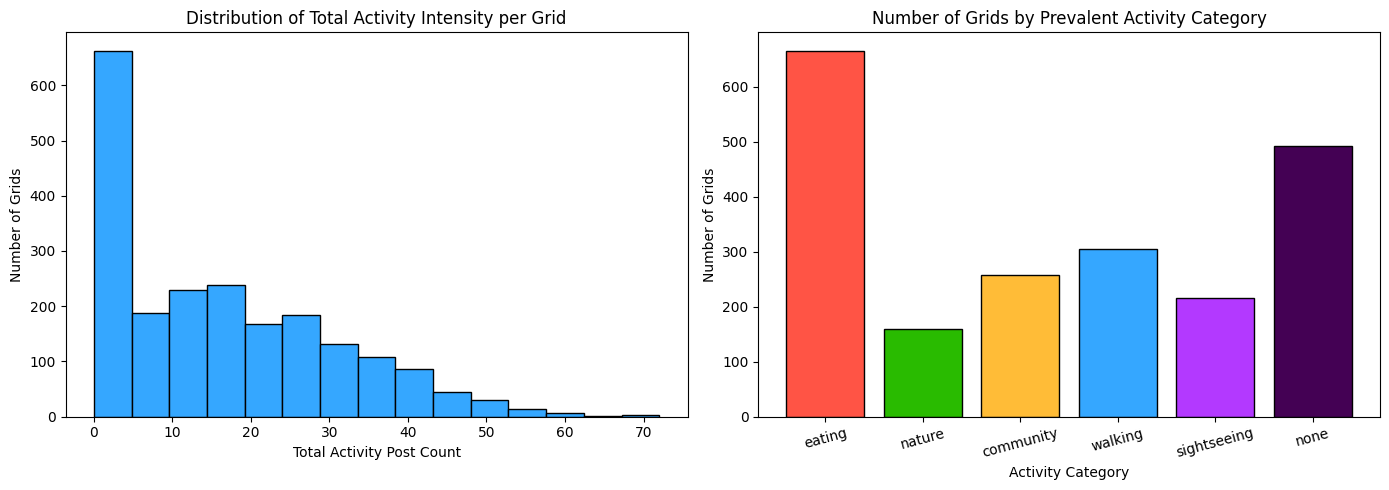

In [30]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Plot two-related charts: (1) Total Activity (all grids) distribution histogram, (2) Bar: Number of Grids by Prevalent Social Activity Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar 1 (now first figure): Histogram of total activity count distribution
axes[0].hist(act_gdf['total_activity'], bins=15, color="#35A7FF", edgecolor="black")
axes[0].set_title('Distribution of Total Activity Intensity per Grid')
axes[0].set_xlabel('Total Activity Post Count')
axes[0].set_ylabel('Number of Grids')

# Bar 2 (move original bar to here): Number of Grids by Prevalent Social Activity Category
prevalent_counts = act_gdf['prevalent_activity'].value_counts().reindex(act_columns + ['none']).fillna(0)
axes[1].bar(prevalent_counts.index, prevalent_counts.values, color=[
    '#FF5445', '#29BB00', '#FFBC37', '#35A7FF', '#B339FF', '#440154'
], edgecolor="black")
axes[1].set_title('Number of Grids by Prevalent Activity Category')
axes[1].set_ylabel('Number of Grids')
axes[1].set_xlabel('Activity Category')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

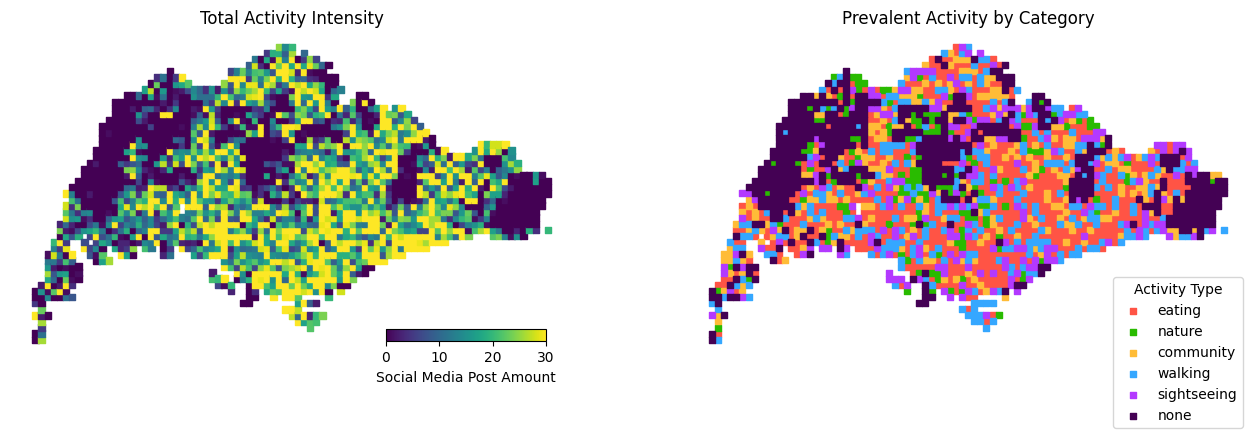

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # one row, two plots

# First plot: show the distribution of total_activity
act_gdf.plot(ax=axes[0], vmin=0, vmax=30, column='total_activity', marker='s', markersize=22)
axes[0].set_title('Total Activity Intensity')
axes[0].axis('off')

# Create a ScalarMappable with the colormap and value range used in the plot
norm = mpl.colors.Normalize(vmin=0, vmax=30)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)  # Use the same colormap as in the plot
sm.set_array([])  # ScalarMappable is only for the colorbar

# Add a colorbar to the figure
# Adjust layout to make room for the colorbar at the bottom
cbar_ax = fig.add_axes([0.36, 0.31, 0.1, 0.015])  # [left, bottom, width, height]

# Create the colorbar with horizontal orientation
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Social Media Post Amount')  # Set colorbar label

# Second plot: display each location colored by most prevalent activity category
activity_colors = {
    'eating': '#FF5445',
    'nature': '#29BB00',
    'community': '#FFBC37',
    'walking': '#35A7FF',
    'sightseeing': '#B339FF',
    'none': '#440154'  # Used for locations with zero values
}

for activity, color in activity_colors.items():
    subset = act_gdf[act_gdf['prevalent_activity'] == activity]
    subset.plot(ax=axes[1], color=color, marker='s', markersize=22, label=activity)

axes[1].set_title('Prevalent Activity by Category')
axes[1].axis('off')
# Move the legend down (below the plot)
axes[1].legend(title="Activity Type", loc='lower right', bbox_to_anchor=(1, -0.25), ncol=1)

plt.show()


## 3. Social Activity Comfort

For each activity category $i$ and location $\mathbf{u}$, **social activity comfort** is defined as the product of social activity **intensity** (post count for that category) and category-specific **comfort sentiment** (average comfort score from the text pipeline):

$$
\text{SocialActivityComfort}_{i,\mathbf{u}} = \text{SocialActivityIntensity}_{i,\mathbf{u}} \times \text{ActivityComfortSentiment}_{i,\mathbf{u}}
$$

Here $\text{SocialActivityIntensity}_{i,\mathbf{u}}$ is $\text{PostNum}_{i,\mathbf{u}}$ as in Section 1, and $\text{ActivityComfortSentiment}_{i,\mathbf{u}}$ is stored in columns `avg_comfort_eating`, …, `avg_comfort_sightseeing`. The product scales observed participation by how positively that activity is associated with comfort at the location. The five fields `social_activity_comfort_eating`, …, `social_activity_comfort_sightseeing` hold these values per grid for downstream modelling.

For each location $\mathbf{u}$, we identify the activity category with the highest social activity comfort (largest product among the five):

$$
\text{PrevalentComfortActivity}_{\mathbf{u}} = \underset{i}{\mathrm{argmax}} \; \text{SocialActivityComfort}_{i,\mathbf{u}}
$$

If $\sum_i \text{SocialActivityComfort}_{i,\mathbf{u}} = 0$, we set $\text{PrevalentComfortActivity}_{\mathbf{u}} = \text{none}$.

Total social activity comfort aggregates across categories (used again in Section 4):

$$
\text{TotalSocialActivityComfort}_{\mathbf{u}} = \sum_{i} \text{SocialActivityComfort}_{i,\mathbf{u}}
$$

These mirror prevalent activity and total activity intensity in Section 2.

/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_17462/2067220965.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.13, 1, 1])  # Leave extra space at the bottom for the colorbar


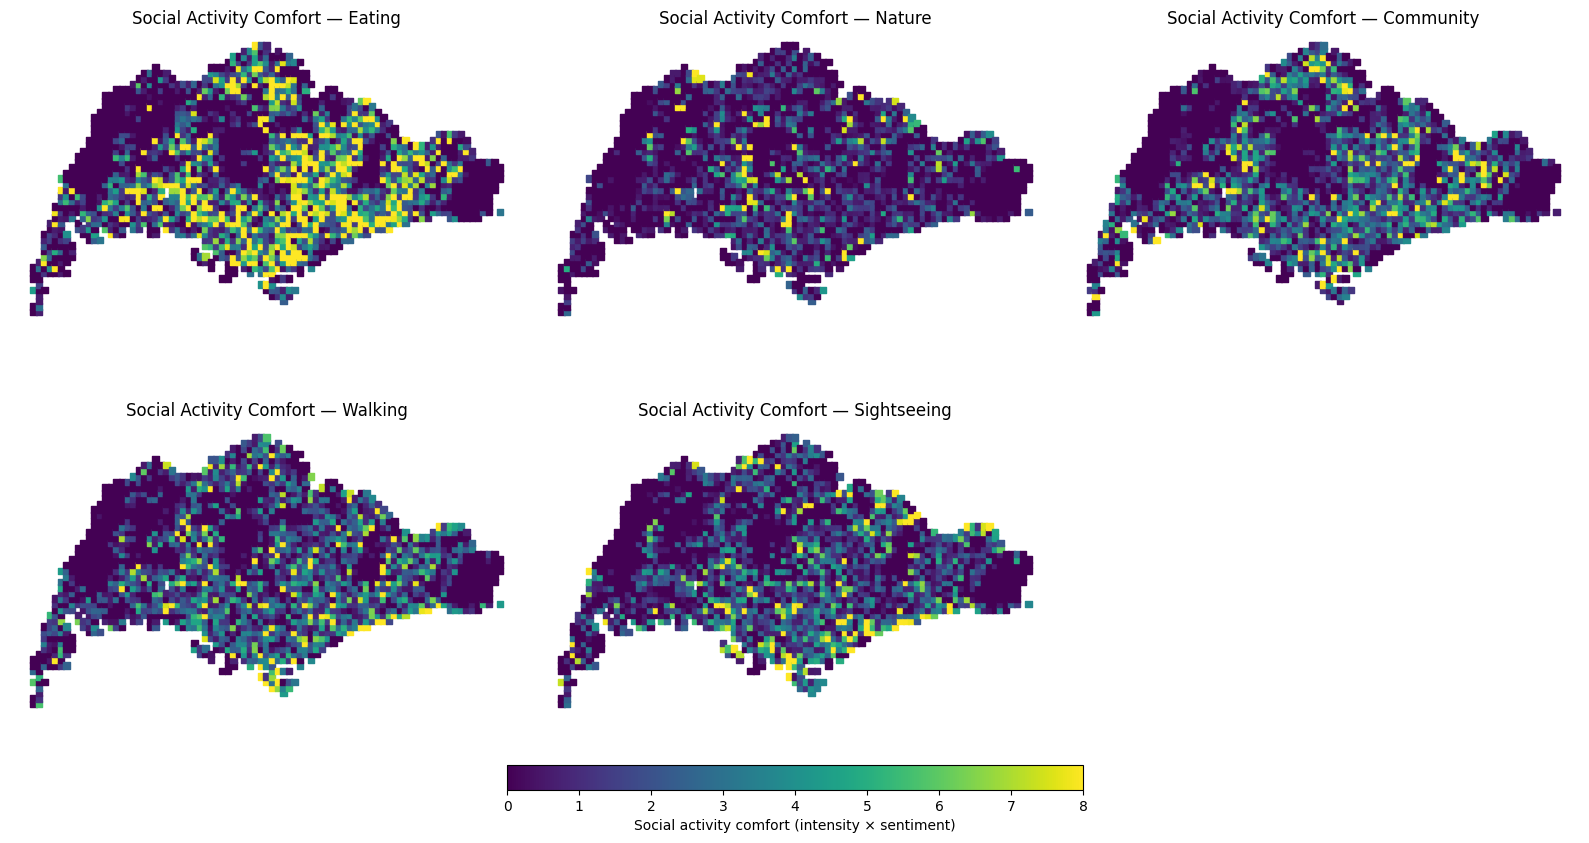

In [32]:
# Plot five social activity comfort maps (same style as Section 2: square markers, viridis color map, axes off)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

comfort_columns = [f'social_activity_comfort_{c}' for c in act_columns]
vmax = 8
vmin = 0.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

title_map = {
    'eating': 'Social Activity Comfort — Eating',
    'nature': 'Social Activity Comfort — Nature',
    'community': 'Social Activity Comfort — Community',
    'walking': 'Social Activity Comfort — Walking',
    'sightseeing': 'Social Activity Comfort — Sightseeing',
}

for idx, category in enumerate(act_columns):
    column = f'social_activity_comfort_{category}'
    act_gdf.plot(
        ax=axes[idx],
        column=column,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        marker='s',
        markersize=22,
        legend=False,
    )
    axes[idx].set_title(title_map[category])
    axes[idx].axis('off')

# Hide the unused sixth axis
axes[5].axis('off')

# Create a horizontal colorbar below the subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add horizontal colorbar at the bottom of the figure
cbar_ax = fig.add_axes([0.32, 0.15, 0.36, 0.025])  # [left, bottom, width, height]
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='Social activity comfort (intensity × sentiment)')

plt.tight_layout(rect=[0, 0.13, 1, 1])  # Leave extra space at the bottom for the colorbar
plt.show()

In [33]:
# Prevalent comfort activity (argmax over per-category social activity comfort) and total (sum), parallel to Section 2.
# idxmax on comfort_cols returns long names (social_activity_comfort_eating); align with act_columns like Section 2.
comfort_cols = [f'social_activity_comfort_{c}' for c in act_columns]
_comfort_for_argmax = act_gdf[comfort_cols].fillna(0).copy()
_comfort_for_argmax.columns = act_columns
act_gdf['prevalent_comfort_activity'] = _comfort_for_argmax.idxmax(axis=1)
act_gdf.loc[_comfort_for_argmax.sum(axis=1) == 0, 'prevalent_comfort_activity'] = 'none'
act_gdf['total_social_activity_comfort'] = act_gdf[comfort_cols].sum(axis=1)

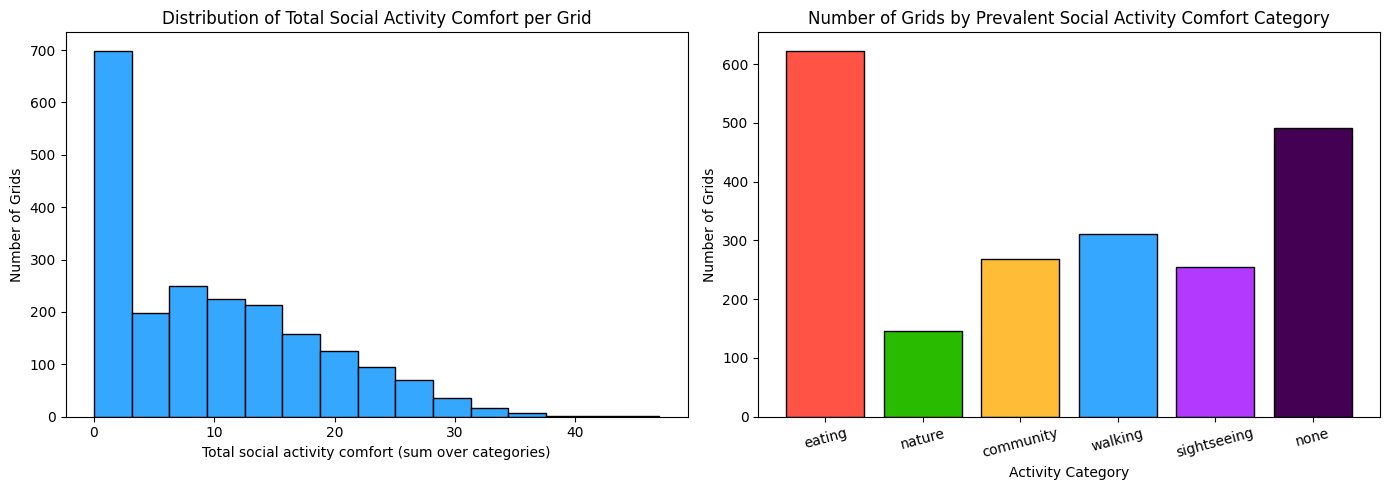

In [34]:
# Two summary charts: (1) distribution of total social activity comfort, (2) grid counts by prevalent comfort activity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(act_gdf['total_social_activity_comfort'], bins=15, color="#35A7FF", edgecolor="black")
axes[0].set_title('Distribution of Total Social Activity Comfort per Grid')
axes[0].set_xlabel('Total social activity comfort (sum over categories)')
axes[0].set_ylabel('Number of Grids')

prevalent_comfort_counts = act_gdf['prevalent_comfort_activity'].value_counts().reindex(act_columns + ['none']).fillna(0)
axes[1].bar(prevalent_comfort_counts.index, prevalent_comfort_counts.values, color=[
    '#FF5445', '#29BB00', '#FFBC37', '#35A7FF', '#B339FF', '#440154'
], edgecolor="black")
axes[1].set_title('Number of Grids by Prevalent Social Activity Comfort Category')
axes[1].set_ylabel('Number of Grids')
axes[1].set_xlabel('Activity Category')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

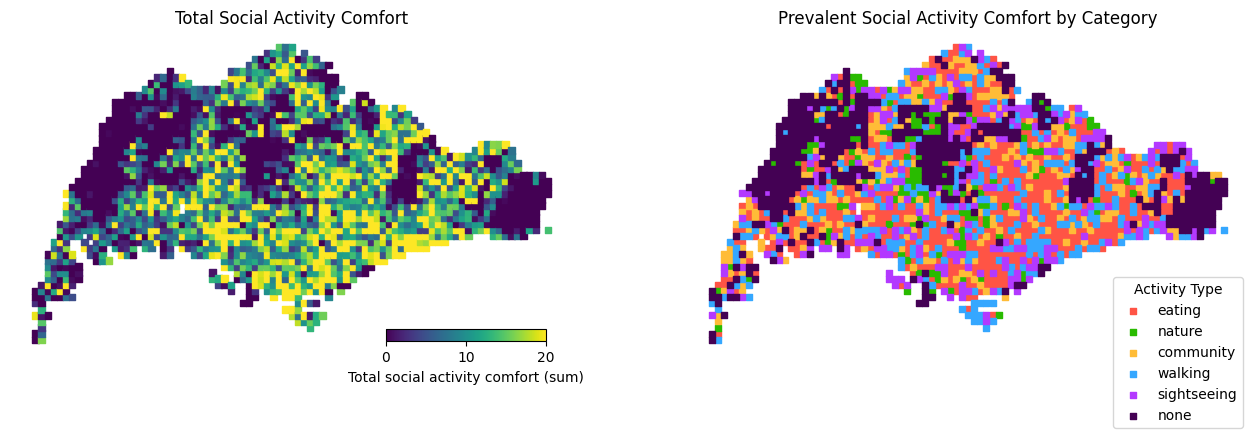

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

vmax_tot = 20
act_gdf.plot(ax=axes[0], vmin=0, vmax=vmax_tot, column='total_social_activity_comfort', marker='s', markersize=22, cmap='viridis')
axes[0].set_title('Total Social Activity Comfort')
axes[0].axis('off')

norm = mpl.colors.Normalize(vmin=0, vmax=vmax_tot)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.36, 0.31, 0.1, 0.015])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Total social activity comfort (sum)')

activity_colors = {
    'eating': '#FF5445',
    'nature': '#29BB00',
    'community': '#FFBC37',
    'walking': '#35A7FF',
    'sightseeing': '#B339FF',
    'none': '#440154',
}

for activity, color in activity_colors.items():
    subset = act_gdf[act_gdf['prevalent_comfort_activity'] == activity]
    subset.plot(ax=axes[1], color=color, marker='s', markersize=22, label=activity)

axes[1].set_title('Prevalent Social Activity Comfort by Category')
axes[1].axis('off')
axes[1].legend(title="Activity Type", loc='lower right', bbox_to_anchor=(1, -0.25), ncol=1)

plt.show()

## 4. Global and Local Moran's I Analytics

This section evaluates spatial autocorrelation of **social activity comfort** (Section 3: intensity × category comfort sentiment) using global Moran's $I$ and local indicators (LISA). We compute global Moran's $I$ for each of the five `social_activity_comfort_*` surfaces. For the Moran scatterplot and LISA map, we use **total social activity comfort** per grid—the sum of the five category comfort values—analogous to total activity intensity in Section 2.


In [36]:
import numpy as np
from libpysal.weights import KNN
from libpysal.weights import lag_spatial
from esda.moran import Moran, Moran_Local

# Create a spatial weights matrix using KNN
coords = np.array([(p.x, p.y) for p in act_gdf.geometry])
w = KNN.from_array(coords, k=8)
w.transform = "r"

comfort_cols = [f"social_activity_comfort_{c}" for c in act_columns]

# Global Moran's I for each category's social activity comfort surface
for c in act_columns:
    col = f"social_activity_comfort_{c}"
    if col in act_gdf.columns:
        x = act_gdf[col]
        global_moran_cat = Moran(x, w)
        print(f"Social activity comfort ({c})")
        print(f"  Moran's I: {global_moran_cat.I:.4f}")
        print(f"  Expected I: {global_moran_cat.EI:.4f}")
        print(f"  Z-Score: {global_moran_cat.z_norm:.4f}")
        print(f"  P-Value: {global_moran_cat.p_norm:.4f}")
        print("-" * 36)
    else:
        print(f"Warning: column '{col}' not found in act_gdf.")

# Aggregate total social activity comfort (parallel to total_activity in Section 2)
act_gdf["total_social_activity_comfort"] = act_gdf[comfort_cols].sum(axis=1)
var_total = act_gdf["total_social_activity_comfort"]

# Global Moran's I and LISA on aggregate comfort (for scatterplot and map)
x = var_total
y = x - np.mean(x)
w_x = lag_spatial(w, var_total)
global_moran = Moran(var_total, w)

local_moran = Moran_Local(var_total, w)
act_gdf["lisa_quadrant"] = local_moran.q
color_map = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink', 0: 'grey'}
act_gdf["color"] = act_gdf["lisa_quadrant"].map(color_map)

Social activity comfort (eating)
  Moran's I: 0.2709
  Expected I: -0.0005
  Z-Score: 25.1471
  P-Value: 0.0000
------------------------------------
Social activity comfort (nature)
  Moran's I: 0.1381
  Expected I: -0.0005
  Z-Score: 12.8400
  P-Value: 0.0000
------------------------------------
Social activity comfort (community)
  Moran's I: 0.2242
  Expected I: -0.0005
  Z-Score: 20.8245
  P-Value: 0.0000
------------------------------------
Social activity comfort (walking)
  Moran's I: 0.1830
  Expected I: -0.0005
  Z-Score: 17.0062
  P-Value: 0.0000
------------------------------------
Social activity comfort (sightseeing)
  Moran's I: 0.2045
  Expected I: -0.0005
  Z-Score: 18.9965
  P-Value: 0.0000
------------------------------------


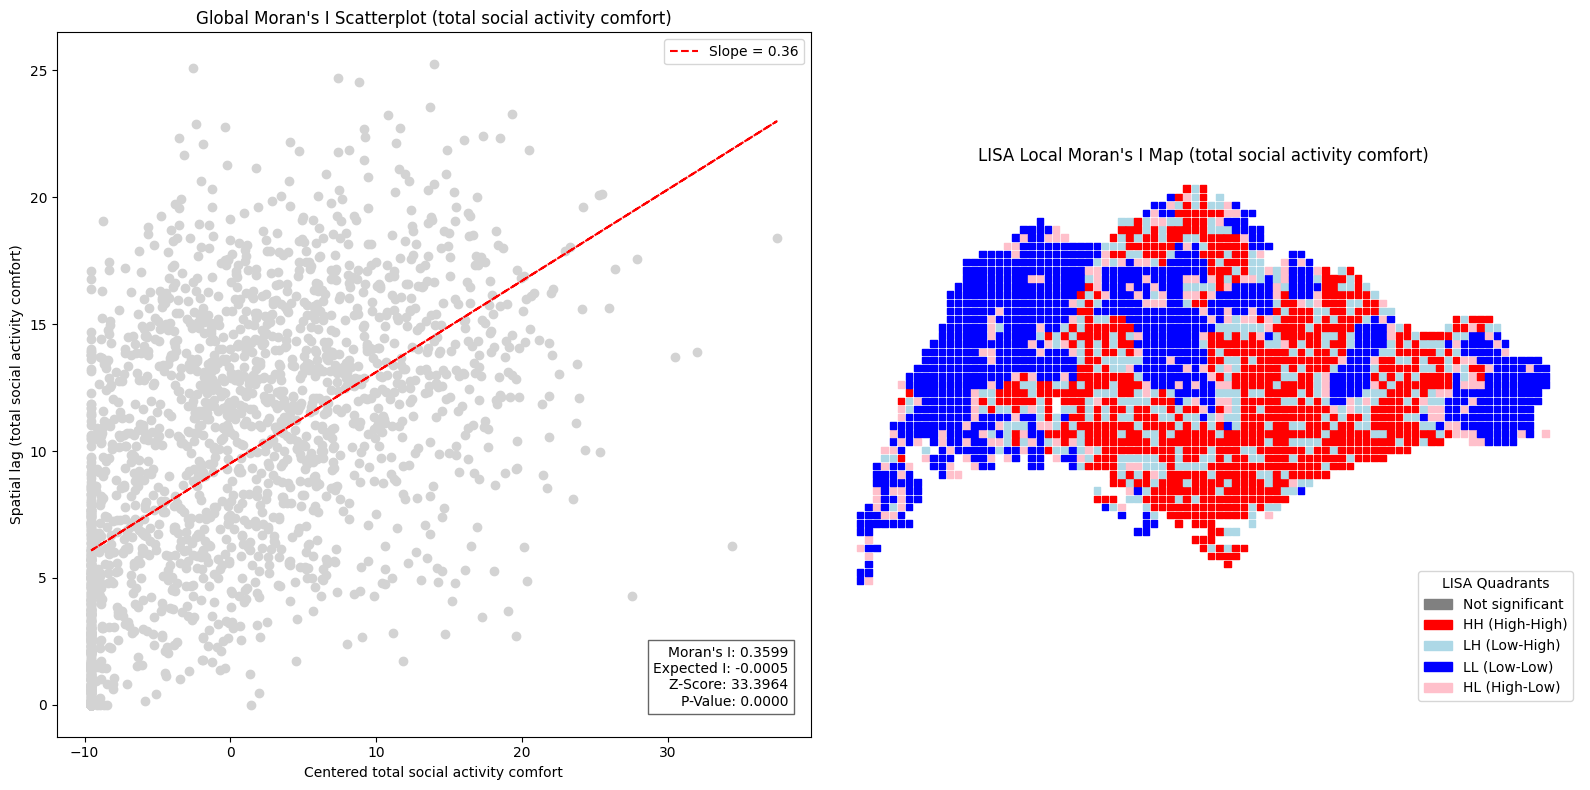

In [37]:
# Plot two related charts in one row: (1) Global Moran's I scatterplot, (2) LISA map (total social activity comfort)
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# (1) Global Moran's I scatterplot (aggregate comfort)
axes[0].scatter(y, w_x, color='lightgrey')
b, a = np.polyfit(y, w_x, 1)
axes[0].plot(y, a + b*y, 'r--', label=f'Slope = {b:.2f}')
axes[0].text(
    0.97, 0.04,
    f"Moran's I: {global_moran.I:.4f}\n"
    f"Expected I: {global_moran.EI:.4f}\n"
    f"Z-Score: {global_moran.z_norm:.4f}\n"
    f"P-Value: {global_moran.p_norm:.4f}",
    transform=axes[0].transAxes,
    bbox=dict(facecolor='white', alpha=0.6),
    verticalalignment='bottom',
    horizontalalignment='right',
)
axes[0].set_xlabel('Centered total social activity comfort')
axes[0].set_ylabel('Spatial lag (total social activity comfort)')
axes[0].set_title("Global Moran's I Scatterplot (total social activity comfort)")
axes[0].legend()

# (2) LISA Local Moran map (aggregate comfort)
# To get a proper legend, we need to manually create legend handles
color_map = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink', 0: 'grey'}
lisa_labels = {
    1: "HH (High-High)", 
    2: "LH (Low-High)", 
    3: "LL (Low-Low)", 
    4: "HL (High-Low)", 
    0: "Not significant"
}
# Sort for legend order
handles = [mpatches.Patch(color=color_map[k], label=lisa_labels[k]) for k in sorted(color_map)]

act_gdf.plot(
    color=act_gdf['color'],
    ax=axes[1],
    marker='s', 
    markersize=22,
    legend=False
)
axes[1].legend(handles=handles, title="LISA Quadrants", loc='lower right', bbox_to_anchor=(1, -0.25))
axes[1].set_title("LISA Local Moran's I Map (total social activity comfort)")
axes[1].axis('off')

plt.tight_layout()
plt.show()